# Morphological alignment demo

Measures how well a tokenizer's boundaries match gold morpheme boundaries from the CELEX lexicon, using boundary-F1 (P/R/F1 over inter-character positions).

In [3]:
from datasets import load_dataset
from importlib.resources import files
from corpus_helpers.read import load_lexicon
from corpus_helpers.tokenizers2 import BPETokenizer, UnigramTokenizer

## 1. Load corpus and lexicon

CELEX is a commercial database (LDC license required). Place the pipe-delimited files in `~/.corpus_helpers/data/` or pass `data_dir` explicitly to `load_celex`.

In [10]:
ds = load_dataset('wikimedia/wikipedia', '20231101.en', split='train', streaming=True)
corpus = [row['text'] for row in ds.take(5000)]
print(f'{len(corpus)} documents, {sum(len(t) for t in corpus):,} chars')

5000 documents, 69,929,392 chars


In [11]:
# lexicon = load_lexicon("path/to/en_morpho_celex.txt") 
lexicon = load_lexicon(files("corpus_helpers") / "data" / "en_morpho_celex.txt")
print(f'{len(lexicon):,} words in lexicon')

# preview a few multi-morpheme entries
compounds = {w: s for w, s in lexicon.items() if len(s) > 1}
print(f'{len(compounds):,} words with internal boundaries')
for w, s in list(compounds.items())[:8]:
    print(f'  {w!r:20s} -> {s}')

41,369 words in lexicon
25,950 words with internal boundaries
  "'tween-decks"       -> ["'tween", '-', 'decks']
  'abandonment'        -> ['abandon', 'ment']
  'abasement'          -> ['abase', 'ment']
  'abatement'          -> ['abate', 'ment']
  'abbreviation'       -> ['abbreviat', 'ion']
  'abdication'         -> ['abdicat', 'ion']
  'abdominal'          -> ['abdomin', 'al']
  'abduction'          -> ['abduct', 'ion']


## 2. Single tokenizer

In [12]:
from corpus_helpers.read import split_word, delete_blank, chain_preprocessors

corpus = chain_preprocessors(corpus[:1],  preprocessors=[split_word, delete_blank])

In [13]:
bpe = BPETokenizer(corpus, vocab_size=4096)

In [14]:
scores = bpe.morphological_alignment(lexicon)
print(f"precision: {scores['precision']:.3f}")
print(f"recall:    {scores['recall']:.3f}")
print(f"F1:        {scores['f1']:.3f}")

precision: 0.286
recall:    0.792
F1:        0.421


## 3. BPE vs Unigram across vocab sizes

In [15]:
import importlib
import corpus_helpers
importlib.reload(corpus_helpers)

UnigramTokenizer = corpus_helpers.tokenizers2.UnigramTokenizer

In [16]:
import pandas as pd

vocab_sizes = [512, 1024, 2048, 4096, 8192, 16384]
rows = []
for vs in vocab_sizes:
    for cls, name in [(BPETokenizer, 'BPE'), (UnigramTokenizer, 'Unigram')]:
        tok = cls(corpus, vocab_size=vs)
        s = tok.morphological_alignment(lexicon)
        rows.append({'vocab_size': vs, 'tokenizer': name, **s})

df = pd.DataFrame(rows)
df

,vocab_size,tokenizer,precision,recall,f1
0,512,BPE,0.208659,0.873736,0.336869
1,512,Unigram,0.195456,0.936759,0.323428
2,1024,BPE,0.242161,0.841752,0.376117
3,1024,Unigram,0.226338,0.910473,0.362549
4,2048,BPE,0.267952,0.815272,0.403340
5,2048,Unigram,0.268961,0.877713,0.411749
6,4096,BPE,0.286310,0.792405,0.420637
7,4096,Unigram,0.268961,0.877713,0.411749
8,8192,BPE,0.286483,0.791557,0.420703
9,8192,Unigram,0.268961,0.877713,0.411749


## 4. Plot F1 curves

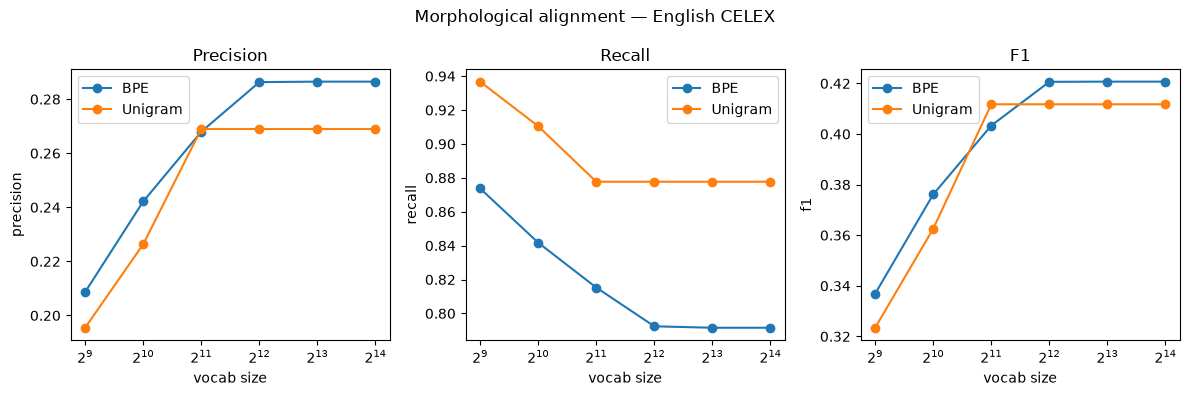

In [17]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(12, 4), sharey=False)
metrics = ['precision', 'recall', 'f1']

for ax, metric in zip(axes, metrics):
    for name, grp in df.groupby('tokenizer'):
        ax.plot(grp['vocab_size'], grp[metric], marker='o', label=name)
    ax.set_xscale('log', base=2)
    ax.set_xlabel('vocab size')
    ax.set_ylabel(metric)
    ax.set_title(metric.capitalize())
    ax.legend()

plt.suptitle('Morphological alignment — English CELEX')
plt.tight_layout()
plt.show()

## 5. Effect of `min_segments` filter

Filter the lexicon to only words with at least N morphemes — useful to focus on clearly segmented compounds.

In [18]:
bpe = BPETokenizer(corpus, vocab_size=4096)

for min_seg in [1, 2, 3]:
    s = bpe.morphological_alignment(lexicon, min_segments=min_seg)
    eligible = sum(1 for segs in lexicon.values() if len(segs) >= min_seg)
    print(f'min_segments={min_seg}: {eligible:,} words  '
          f"P={s['precision']:.3f}  R={s['recall']:.3f}  F1={s['f1']:.3f}")




min_segments=1: 41,369 words  P=0.286  R=0.792  F1=0.421
min_segments=2: 25,950 words  P=0.398  R=0.792  F1=0.530
min_segments=3: 12,121 words  P=0.503  R=0.865  F1=0.636
